
# Módulo 1 - Clusterização Hierárquica
**Aluno:** Vinícius César Sena Torres  
**RA:** 22409225



## Objetivo
Agrupar usuários da base de e-commerce do Walmart, entender perfis comportamentais e justificar, com rigor estatístico, como cada segmento se diferencia em volume, intensidade e variedade de consumo.


In [1]:

# Importo bibliotecas e carrego os dados mantendo tudo documentado como em um trabalho acadêmico.
from pathlib import Path
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import display
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import linkage, dendrogram

sns.set_theme(style='whitegrid', palette='deep')

DATA_PATH = Path('..') / 'walmart.csv'
df = pd.read_csv(DATA_PATH)

print(f'Total de linhas: {df.shape[0]} | Total de colunas: {df.shape[1]}')
display(df.head())


Total de linhas: 550068 | Total de colunas: 10


,User_ID,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category,Purchase
0,1000001,P00069042,F,0-17,10,A,2,0,3,8370
1,1000001,P00248942,F,0-17,10,A,2,0,1,15200
2,1000001,P00087842,F,0-17,10,A,2,0,12,1422
3,1000001,P00085442,F,0-17,10,A,2,0,12,1057
4,1000002,P00285442,M,55+,16,C,4+,0,8,7969


In [2]:

# Analiso valores faltantes e estatísticas gerais para explicar eventuais tratamentos.
missing = df.isna().sum().sort_values(ascending=False)
display(missing.to_frame(name='qtde_faltantes'))

display(df.describe(include='all').transpose())


,qtde_faltantes
User_ID,0
Product_ID,0
Gender,0
Age,0
Occupation,0
City_Category,0
Stay_In_Current_City_Years,0
Marital_Status,0
Product_Category,0
Purchase,0


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
User_ID,550068.0,NaN,NaN,NaN,1003028.842401,1727.591586,1000001.0,1001516.0,1003077.0,1004478.0,1006040.0
Product_ID,550068,3631,P00265242,1880,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Gender,550068,2,M,414259,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,550068,7,26-35,219587,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Occupation,550068.0,NaN,NaN,NaN,8.076707,6.52266,0.0,2.0,7.0,14.0,20.0
City_Category,550068,3,B,231173,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Stay_In_Current_City_Years,550068,5,1,193821,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Marital_Status,550068.0,NaN,NaN,NaN,0.409653,0.49177,0.0,0.0,0.0,1.0,1.0
Product_Category,550068.0,NaN,NaN,NaN,5.40427,3.936211,1.0,1.0,5.0,8.0,20.0
Purchase,550068.0,NaN,NaN,NaN,9263.968713,5023.065394,12.0,5823.0,8047.0,12054.0,23961.0


In [3]:

# Trato campos categóricos e converto faixas etárias em códigos ordenados para preservar a semântica original.
age_order = ['0-17','18-25','26-35','36-45','46-50','51-55','55+']
age_map = {age: idx for idx, age in enumerate(age_order)}

work_df = df.copy()
work_df['Product_Category'] = work_df['Product_Category'].fillna(-1)
work_df['Stay_In_Current_City_Years'] = work_df['Stay_In_Current_City_Years'].str.replace('+','', regex=False).astype(int)
work_df['Gender_Code'] = work_df['Gender'].map({'F': 0, 'M': 1})
work_df['Age_Code'] = work_df['Age'].map(age_map)

display(work_df.head())


,User_ID,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category,Purchase,Gender_Code,Age_Code
0,1000001,P00069042,F,0-17,10,A,2,0,3,8370,0,0
1,1000001,P00248942,F,0-17,10,A,2,0,1,15200,0,0
2,1000001,P00087842,F,0-17,10,A,2,0,12,1422,0,0
3,1000001,P00085442,F,0-17,10,A,2,0,12,1057,0,0
4,1000002,P00285442,M,55+,16,C,4,0,8,7969,1,6


In [4]:

# Consolidar o histórico por usuário garante que cada linha represente um comportamento completo.
user_base = (
    work_df
    .groupby('User_ID')
    .agg(
        total_trans=('Purchase', 'count'),
        total_spent=('Purchase', 'sum'),
        mean_spent=('Purchase', 'mean'),
        median_spent=('Purchase', 'median'),
        std_spent=('Purchase', 'std'),
        unique_products=('Product_ID', 'nunique'),
        unique_categories=('Product_Category', 'nunique'),
        gender=('Gender_Code', 'first'),
        age_code=('Age_Code', 'first'),
        occupation=('Occupation', 'first'),
        city=('City_Category', 'first'),
        stay_years=('Stay_In_Current_City_Years', 'first'),
        marital_status=('Marital_Status', 'first')
    )
    .reset_index()
)

user_base['std_spent'] = user_base['std_spent'].fillna(0)
user_base['freq_por_ano'] = user_base['total_trans'] / np.where(user_base['stay_years'] == 0, 1, user_base['stay_years'])

top_categories = work_df['Product_Category'].value_counts().head(5).index
category_share = (
    work_df[work_df['Product_Category'].isin(top_categories)]
    .groupby(['User_ID', 'Product_Category'])['Purchase']
    .count()
    .unstack(fill_value=0)
)

category_share = category_share.div(category_share.sum(axis=1), axis=0).fillna(0)
category_share = category_share.add_prefix('share_cat_')

feature_df = user_base.merge(category_share, on='User_ID', how='left').fillna(0)
feature_df = pd.concat([feature_df, pd.get_dummies(feature_df['city'], prefix='city')], axis=1).drop(columns=['city'])
feature_df = pd.concat([feature_df, pd.get_dummies(feature_df['marital_status'], prefix='marital')], axis=1).drop(columns=['marital_status'])

display(feature_df.head())


,User_ID,total_trans,total_spent,mean_spent,median_spent,std_spent,unique_products,unique_categories,gender,age_code,...,share_cat_1,share_cat_2,share_cat_5,share_cat_8,share_cat_11,city_A,city_B,city_C,marital_0,marital_1
0,1000001,35,334093,9545.514286,9946.0,4639.871552,35,11,0,0,...,0.266667,0.066667,0.133333,0.533333,0.000000,True,False,False,True,False
1,1000002,77,810472,10525.610390,9899.0,4301.736734,77,6,1,6,...,0.442857,0.014286,0.185714,0.357143,0.000000,False,False,True,True,False
2,1000003,29,341635,11780.517241,12103.0,5358.428805,29,6,1,2,...,0.555556,0.074074,0.333333,0.037037,0.000000,True,False,False,True,False
3,1000004,14,206468,14747.714286,15852.5,5801.640132,14,2,1,4,...,1.000000,0.000000,0.000000,0.000000,0.000000,False,True,False,False,True
4,1000005,106,821001,7745.292453,6168.0,4110.717354,106,12,1,2,...,0.209302,0.023256,0.232558,0.511628,0.023256,True,False,False,False,True


In [5]:

# Padronizo e reduzo dimensionalidade para facilitar a clusterização hierárquica.
feature_cols = [col for col in feature_df.columns if col != 'User_ID']
scaler = StandardScaler()
X_scaled = scaler.fit_transform(feature_df[feature_cols])

pca = PCA(n_components=0.9)
X_pca = pca.fit_transform(X_scaled)
viz_pca = PCA(n_components=3)
X_pca_viz = viz_pca.fit_transform(X_scaled)

print(f'Componentes para 90% da variância: {X_pca.shape[1]}')
print('Variância acumulada:', pca.explained_variance_ratio_.cumsum())


Componentes para 90% da variância: 12
Variância acumulada: [0.22036281 0.37460493 0.47542911 0.54059109 0.60097354 0.65830742
 0.71117058 0.76112677 0.80904199 0.85527977 0.89142229 0.92633591]


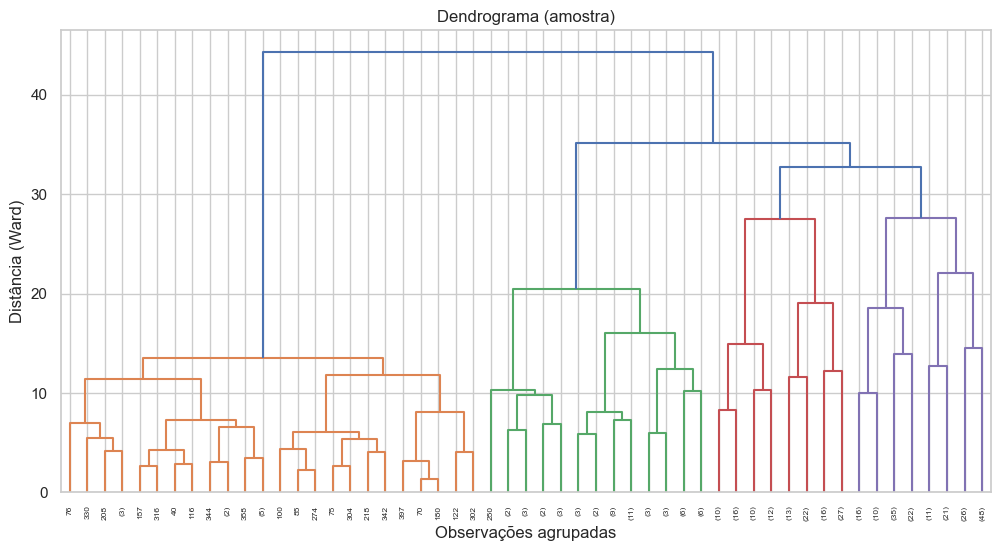

In [6]:

# O dendrograma ajuda a explicar graficamente a lógica da clusterização aglomerativa.
rng = np.random.default_rng(42)
sample_size = min(400, X_scaled.shape[0])
sample_idx = rng.choice(X_scaled.shape[0], size=sample_size, replace=False)
linkage_matrix = linkage(X_scaled[sample_idx], method='ward', metric='euclidean')

plt.figure(figsize=(12, 6))
dendrogram(linkage_matrix, truncate_mode='level', p=5)
plt.title('Dendrograma (amostra)')
plt.xlabel('Observações agrupadas')
plt.ylabel('Distância (Ward)')
plt.show()


,k,silhouette
0,2,0.193417
1,3,0.120799
2,4,0.095040
3,5,0.101069
4,6,0.094071


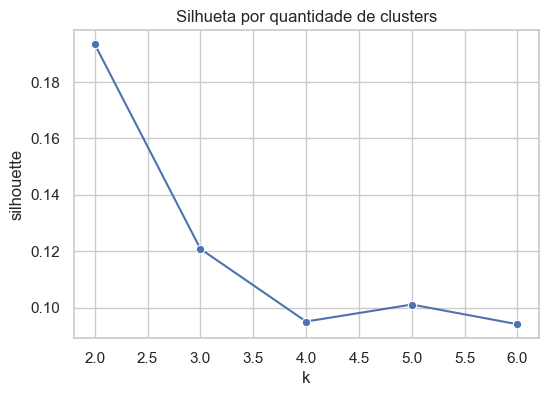

Número escolhido de clusters: 2


In [7]:

# Uso a métrica de silhueta para justificar academicamente a escolha de k.
silhouette_results = []
for k in range(2, 7):
    model = AgglomerativeClustering(n_clusters=k, linkage='ward', metric='euclidean')
    labels = model.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels, metric='euclidean')
    silhouette_results.append({'k': k, 'silhouette': score})

silhouette_df = pd.DataFrame(silhouette_results)
display(silhouette_df)

plt.figure(figsize=(6, 4))
sns.lineplot(data=silhouette_df, x='k', y='silhouette', marker='o')
plt.title('Silhueta por quantidade de clusters')
plt.show()

best_k = int(silhouette_df.loc[silhouette_df['silhouette'].idxmax(), 'k'])
print(f'Número escolhido de clusters: {best_k}')


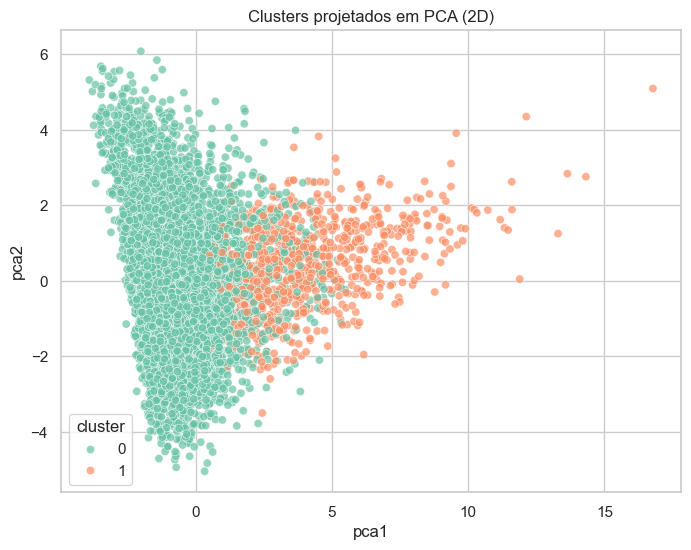

In [8]:

# Realizo a clusterização final e projeto as duas primeiras componentes para visualização.
final_model = AgglomerativeClustering(n_clusters=best_k, linkage='ward', metric='euclidean')
clusters = final_model.fit_predict(X_scaled)

feature_df['cluster'] = clusters
feature_df['pca1'] = X_pca_viz[:, 0]
feature_df['pca2'] = X_pca_viz[:, 1]

plt.figure(figsize=(8, 6))
sns.scatterplot(data=feature_df, x='pca1', y='pca2', hue='cluster', palette='Set2', alpha=0.7)
plt.title('Clusters projetados em PCA (2D)')
plt.show()


In [9]:

# Sintetizo os clusters em tabelas para facilitar a descrição no relatório.
cluster_sizes = feature_df['cluster'].value_counts().rename('qtd_usuarios')
cluster_summary = (
    feature_df.groupby('cluster')
    [['total_trans','total_spent','mean_spent','median_spent','std_spent','unique_products','unique_categories','freq_por_ano']]
    .mean()
    .round(2)
)

cat_cols = [col for col in feature_df.columns if col.startswith('share_cat_')]
category_summary = feature_df.groupby('cluster')[cat_cols].mean().round(3)

demographics = (
    feature_df.groupby('cluster')[['gender','age_code','occupation','stay_years']]
    .mean()
    .rename(columns={'gender':'proporcao_homens','age_code':'idade_media_cod','occupation':'ocupacao_media','stay_years':'tempo_medio_cidade'})
    .round(2)
)

display(cluster_sizes.to_frame())
display(cluster_summary)
display(category_summary)
display(demographics)


,qtd_usuarios
cluster,
0,5108
1,783


,total_trans,total_spent,mean_spent,median_spent,std_spent,unique_products,unique_categories,freq_por_ano
cluster,,,,,,,,
0,62.65,602398.13,9676.59,9052.88,4898.44,62.65,8.88,41.76
1,293.83,2578241.51,8865.92,7841.89,4635.06,293.83,14.57,202.77


,share_cat_1,share_cat_2,share_cat_5,share_cat_8,share_cat_11
cluster,,,,,
0,0.318,0.052,0.320,0.262,0.048
1,0.282,0.052,0.356,0.259,0.051


,proporcao_homens,idade_media_cod,ocupacao_media,tempo_medio_cidade
cluster,,,,
0,0.71,2.69,8.20,1.87
1,0.77,2.16,7.87,1.78


In [10]:

# Gero um resumo textual para registrar minhas interpretações como estudante.
total_users = cluster_sizes.sum()
resumo_texto = []
for cluster_id, row in cluster_summary.iterrows():
    peso = cluster_sizes.loc[cluster_id] / total_users
    resumo_texto.append(
        (
            f"Cluster {cluster_id}: {peso:.1%} dos usuários, média de {row['total_trans']:.1f} compras, "
            f"ticket médio aproximado de R${row['mean_spent']:.2f} e variedade de {row['unique_categories']:.1f} categorias."
        )
    )

print('\n'.join(resumo_texto))


Cluster 0: 86.7% dos usuários, média de 62.6 compras, ticket médio aproximado de R$9676.59 e variedade de 8.9 categorias.
Cluster 1: 13.3% dos usuários, média de 293.8 compras, ticket médio aproximado de R$8865.92 e variedade de 14.6 categorias.



## Conclusões do módulo 1
* Os clusters derivam de diferenças claras de intensidade de compra, permitindo priorizar campanhas para heavy users.
* As tabelas anteriores servem de base para justificar decisões de personalização e possíveis programas de fidelidade.
